In [1]:
# If needed once in this environment:
# %pip install python-dotenv sqlalchemy pyodbc pandas numpy scikit-learn lifelines

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from lifelines import CoxPHFitter
except ImportError:
    CoxPHFitter = None

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table

In [3]:
# Paths
project_root = Path.cwd().resolve().parent  # .../yieldCurve_augmenting
env_path = project_root / '.env'
sql_path = project_root / 'sql_scripts' / 'jcx_raw_harvey_v15.sql'

# Load SQL and execute temp-table workflow
engine = create_db_engine(env_path)
setup_sql = read_sql_file(sql_path)

raw_df = execute_sql_and_read_temp_table(engine, setup_sql, '#t17_combined')

print('SQL loaded from:', sql_path)
print('Using env file:', env_path)
print('raw_df shape:', raw_df.shape)
raw_df.head()

SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_raw_harvey_v15.sql
Using env file: /Users/starsrain/2025_concord/yieldCurve_augmenting/.env
raw_df shape: (1045366, 34)


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,isRecentLoan,...,AppWeek,LoanStatus,CustType,Frequency,OriginatedAmount,OriginationDate,InstallmentNumberMFG,TransactionDate,TxYear,TxMonth
0,71553269,1,I1533800-0,6,0.0,825,144,6,2023-03-31,0,...,1,R,NEW,B,700.0,2023-01-06,6,None,NaN,NaN
1,104504982,5,I1533806-0,1,40.0,111,144,8,2023-01-13,0,...,1,D,NEW,W,200.0,2023-01-06,1,2023-01-13,2023.0,1.0
2,104504982,5,I1533806-0,2,80.0,111,144,8,2023-01-20,0,...,1,D,NEW,W,200.0,2023-01-06,2,2023-01-20,2023.0,1.0
3,104504982,5,I1533806-0,3,32.0,111,144,8,2023-01-27,0,...,1,D,NEW,W,200.0,2023-01-06,3,2023-01-26,2023.0,1.0
4,104504982,5,I1533806-0,4,32.0,779,144,8,2023-02-03,0,...,1,D,NEW,W,200.0,2023-01-06,4,2023-02-07,2023.0,2.0


In [4]:
raw_df.columns

Index(['Application_ID', 'PortFolioID', 'LoanID', 'InstallmentNumber',
       'InstallRealizedPayment', 'installStatus', 'iPaymentMode',
       'TotalInstallsNumber', 'InstallmentDueDate', 'isRecentLoan',
       'LoanPaidOffThisInstall', 'isLoanDefault', 'isInstallDefault',
       'ThirdPartyCollected', 'PartialCollected', 'InstallCollected',
       'EarlyCollected', 'isDenyNew', 'isAllVoided', 'isArrangementInstall',
       'is3rdPartyInstall', 'TotalRealizedPayment', 'AppYear', 'AppMonth',
       'AppWeek', 'LoanStatus', 'CustType', 'Frequency', 'OriginatedAmount',
       'OriginationDate', 'InstallmentNumberMFG', 'TransactionDate', 'TxYear',
       'TxMonth'],
      dtype='object')

In [5]:
# Quick reconciliation view: SQL total vs recomputed from installment payin.
# Payin reconciliation: deduped loan total vs summed installment realized payment.
# Goal: check whether SUM(InstallRealizedPayment) per LoanID matches TotalRealizedPayment (dedup by LoanID).

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f'Missing expected columns. Tried: {candidates}')

loan_col = _pick_col(raw_df, ['LoanID'])
total_col = _pick_col(raw_df, ['TotalRealizedPayment', 'TotalRealizedPayin'])
install_col = _pick_col(raw_df, ['InstallRealizedPayment', 'PaidOffThisInstall'])

work = raw_df[[loan_col, total_col, install_col]].copy()
work[total_col] = pd.to_numeric(work[total_col], errors='coerce').fillna(0.0)
work[install_col] = pd.to_numeric(work[install_col], errors='coerce').fillna(0.0)

# Canonical loan-level total (dedup by loan).
loan_sql_total = (
    work.groupby(loan_col, as_index=False)[total_col]
    .first()
    .rename(columns={total_col: 'sql_total_dedup'})
)

# Recomputed from installment-level realized payments.
loan_install_total = (
    work.groupby(loan_col, as_index=False)[install_col]
    .sum()
    .rename(columns={install_col: 'install_sum_total'})
)

recon_loan = loan_sql_total.merge(loan_install_total, on=loan_col, how='outer').fillna(0.0)
recon_loan['abs_gap'] = (recon_loan['sql_total_dedup'] - recon_loan['install_sum_total']).abs()
recon_loan['signed_gap'] = recon_loan['sql_total_dedup'] - recon_loan['install_sum_total']
recon_loan['gap_pct_vs_sql'] = np.where(
    recon_loan['sql_total_dedup'] != 0,
    recon_loan['signed_gap'] / recon_loan['sql_total_dedup'],
    np.nan,
)

recon_summary = pd.DataFrame([
    {
        'loan_count': int(recon_loan[loan_col].nunique()),
        'sum_sql_total_dedup': float(recon_loan['sql_total_dedup'].sum()),
        'sum_install_sum_total': float(recon_loan['install_sum_total'].sum()),
        'signed_gap_total': float(recon_loan['signed_gap'].sum()),
        'abs_gap_total': float(recon_loan['abs_gap'].sum()),
        'gap_pct_total_vs_sql': float(
            (recon_loan['signed_gap'].sum() / recon_loan['sql_total_dedup'].sum())
            if recon_loan['sql_total_dedup'].sum() != 0 else np.nan
        ),
        'loans_with_nonzero_gap': int((recon_loan['abs_gap'] > 1e-6).sum()),
    }
])

print('Columns used ->', {'loan_col': loan_col, 'total_col': total_col, 'install_col': install_col})
print('Reconciliation summary:')
display(recon_summary)

print('Top 20 loans by absolute gap:')
display(recon_loan.sort_values('abs_gap', ascending=False).head(20))



Columns used -> {'loan_col': 'LoanID', 'total_col': 'TotalRealizedPayment', 'install_col': 'InstallRealizedPayment'}
Reconciliation summary:


,loan_count,sum_sql_total_dedup,sum_install_sum_total,signed_gap_total,abs_gap_total,gap_pct_total_vs_sql,loans_with_nonzero_gap
0,206175,2.508779e+08,2.491960e+08,1681945.65,1687308.59,0.006704,3424


Top 20 loans by absolute gap:


,LoanID,sql_total_dedup,install_sum_total,abs_gap,signed_gap,gap_pct_vs_sql
9906,I1582550-0,3150.00,0.0,3150.00,3150.00,1.000000
69152,I1914011-0,4175.00,1125.0,3050.00,3050.00,0.730539
138083,I2263718-0,5625.00,2625.0,3000.00,3000.00,0.533333
159897,I2400169-0,3650.00,800.0,2850.00,2850.00,0.780822
144466,I2303779-0,3533.11,735.0,2798.11,2798.11,0.791968
38616,I1744919-0,5345.20,2617.5,2727.70,2727.70,0.510308
128677,I2213610-0,3199.09,510.0,2689.09,2689.09,0.840580
141821,I2285886-0,5550.00,2934.0,2616.00,2616.00,0.471351
172126,I2449043-0,3025.00,450.0,2575.00,2575.00,0.851240
115630,I2160445-0,2931.05,400.0,2531.05,2531.05,0.863530


In [6]:
# Among reconciliation-variance loans: latest (most recent) origination date
gap_tol = 1e-6
variance_loans = recon_loan.loc[recon_loan['abs_gap'] > gap_tol, loan_col].unique()

if 'OriginationDate' not in raw_df.columns:
    raise ValueError('raw_df missing OriginationDate for variance-loan origination check')

orig = raw_df[raw_df[loan_col].isin(variance_loans)][[loan_col, 'OriginationDate']].copy()
orig['OriginationDate'] = pd.to_datetime(orig['OriginationDate'], errors='coerce')

# One origination per loan (use max if multiple rows differ).
loan_orig = orig.groupby(loan_col, as_index=False)['OriginationDate'].max()

latest = loan_orig['OriginationDate'].max()
earliest = loan_orig['OriginationDate'].min()

print(f'Loans with abs_gap > {gap_tol}: {len(variance_loans):,}')
print('Most recent origination date among those loans:', latest)
print('Earliest origination date among those loans:', earliest)

display(loan_orig.sort_values('OriginationDate', ascending=False).head(15).rename(columns={loan_col: 'LoanID'}))

Loans with abs_gap > 1e-06: 3,424
Most recent origination date among those loans: 2026-04-22 00:00:00
Earliest origination date among those loans: 2023-01-03 00:00:00


,LoanID,OriginationDate
3423,I2614583-0,2026-04-22
3422,I2595851-0,2026-04-08
3421,I2576423-0,2026-03-18
3420,I2576267-0,2026-03-18
3419,I2573653-0,2026-03-16
3418,I2573457-0,2026-03-14
3416,I2569120-0,2026-03-12
3417,I2570714-0,2026-03-11
3415,I2565294-0,2026-03-04
3414,I2561767-0,2026-02-27


In [7]:
# Check from the raw_df loanID I2589219-0

check_loan_id = 'I2348690-0'
if check_loan_id not in raw_df[loan_col].values:
    print(f"LoanID {check_loan_id} not found in raw_df[{loan_col}]")
else:
    print(f"Rows for LoanID {check_loan_id}:")
    display(raw_df[raw_df[loan_col] == check_loan_id])

Rows for LoanID I2348690-0:


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,isRecentLoan,...,AppWeek,LoanStatus,CustType,Frequency,OriginatedAmount,OriginationDate,InstallmentNumberMFG,TransactionDate,TxYear,TxMonth
904499,100158662,1,I2348690-0,1,225.0,111,144,19,2025-05-16,0,...,19,D,RETURN,M,1500.0,2025-05-09,1,2025-05-15,2025.0,5.0
904500,100158662,1,I2348690-0,2,300.0,111,144,19,2025-05-23,0,...,19,D,RETURN,M,1500.0,2025-05-09,2,2025-05-22,2025.0,5.0
904501,100158662,1,I2348690-0,3,300.0,111,144,19,2025-05-30,0,...,19,D,RETURN,M,1500.0,2025-05-09,3,2025-05-29,2025.0,5.0
904502,100158662,1,I2348690-0,4,300.0,111,144,19,2025-06-06,0,...,19,D,RETURN,M,1500.0,2025-05-09,4,2025-06-05,2025.0,6.0
904503,100158662,1,I2348690-0,5,450.0,111,144,19,2025-06-13,0,...,19,D,RETURN,M,1500.0,2025-05-09,5,2025-06-12,2025.0,6.0
904504,100158662,1,I2348690-0,6,420.0,111,144,19,2025-06-20,0,...,19,D,RETURN,M,1500.0,2025-05-09,6,2025-06-18,2025.0,6.0
904505,100158662,1,I2348690-0,7,390.0,111,144,19,2025-06-27,0,...,19,D,RETURN,M,1500.0,2025-05-09,7,2025-06-26,2025.0,6.0
904506,100158662,1,I2348690-0,8,360.0,111,144,19,2025-07-03,0,...,19,D,RETURN,M,1500.0,2025-05-09,8,2025-07-02,2025.0,7.0
904507,100158662,1,I2348690-0,9,330.0,111,144,19,2025-07-11,0,...,19,D,RETURN,M,1500.0,2025-05-09,9,2025-07-10,2025.0,7.0
904508,100158662,1,I2348690-0,10,300.0,111,144,19,2025-07-18,0,...,19,D,RETURN,M,1500.0,2025-05-09,10,2025-07-17,2025.0,7.0


### Exclude loans with installment-sum vs SQL total mismatch (likely duplicate rows in combined output).

In [ ]:
""" # Exclude loans with installment-sum vs SQL total mismatch (likely duplicate rows in combined output).
gap_tol = 1e-6
bad_loan_ids = recon_loan.loc[recon_loan['abs_gap'] > gap_tol, loan_col]
n_bad_loans = bad_loan_ids.nunique()
rows_before = len(raw_df)
raw_df = raw_df[~raw_df[loan_col].isin(bad_loan_ids)].copy()
rows_after = len(raw_df)
print(
    f'Excluded {n_bad_loans} loans with abs_gap > {gap_tol}; '
    f'raw_df rows {rows_before} -> {rows_after}'
) """

Excluded 3180 loans with abs_gap > 1e-06; raw_df rows 1012869 -> 995114


In [ ]:
""" from pathlib import Path

# Save cleaned raw_df after reconciliation filter (run reconciliation cells first).
out_dir = Path('/Users/starsrain/2026_concord_advice/apr2026_concord/apr26_harvey_support_files/apr26_raw_3_year')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / '0428_raw_v1.csv'
raw_df.to_csv(out_path, index=False)
print('Wrote:', out_path)
print('rows:', len(raw_df), 'cols:', raw_df.shape[1]) """

Wrote: /Users/starsrain/2026_concord_advice/apr2026_concord/apr26_harvey_support_files/apr26_raw_3_year/0428_raw_v1.csv
rows: 995114 cols: 32


---

## Recent Cohort AA Check

In [8]:
# Weekly loan counts from application date >= 2026-03-09 through latest in data
# Unique LoanID per week (installment rows deduped to loan × week).

start_date = pd.Timestamp('2025-03-09')

loan_col = 'LoanID'
if loan_col not in raw_df.columns:
    raise ValueError('raw_df missing LoanID')

wk = raw_df[[loan_col]].copy()

if 'ApplicationDate' in raw_df.columns:
    wk['app_dt'] = pd.to_datetime(raw_df['ApplicationDate'], errors='coerce')
    wk['week_start'] = wk['app_dt'].dt.to_period('W-MON').dt.start_time
else:
    # #t17_combined carries AppYear / AppWeek (no ApplicationDate). Approximate week as ISO Monday of (AppYear, AppWeek).
    # Note: SQL DATEPART(WEEK) may not match ISO week numbers; align in SQL if you need exact calendar weeks.
    if 'AppYear' not in raw_df.columns or 'AppWeek' not in raw_df.columns:
        raise ValueError('raw_df has no ApplicationDate and no AppYear/AppWeek — add ApplicationDate in SQL or these columns.')
    ay = pd.to_numeric(raw_df['AppYear'], errors='coerce')
    aw = pd.to_numeric(raw_df['AppWeek'], errors='coerce')

    def _iso_monday(row):
        y, w = row['AppYear'], row['AppWeek']
        if pd.isna(y) or pd.isna(w):
            return pd.NaT
        try:
            return pd.Timestamp.fromisocalendar(int(y), int(w), 1)
        except (ValueError, OverflowError):
            return pd.NaT

    wk['app_dt'] = pd.DataFrame({'AppYear': ay, 'AppWeek': aw}).apply(_iso_monday, axis=1)
    wk['week_start'] = wk['app_dt']

wk = wk.dropna(subset=['week_start'])
wk = wk[wk['app_dt'] >= start_date].copy()

loan_week = wk[[loan_col, 'week_start']].drop_duplicates()
weekly_counts = (
    loan_week.groupby('week_start', as_index=False)[loan_col]
    .nunique()
    .rename(columns={loan_col: 'unique_loan_count'})
    .sort_values('week_start')
)

# --- FPD by application week (same row universe as #monthly_summary: normal installments only) ---
need = {
    'InstallmentNumber', 'TotalInstallsNumber', 'isLoanDefault',
    'isRecentLoan', 'isDenyNew', 'isAllVoided',
}
miss = need - set(raw_df.columns)
if miss:
    raise ValueError(f'raw_df missing columns for FPD: {sorted(miss)}')

_iarr = raw_df.get('isArrangementInstall', pd.Series(0, index=raw_df.index))
_i3rd = raw_df.get('is3rdPartyInstall', pd.Series(0, index=raw_df.index))
cohort_ids = loan_week[loan_col].unique()
_base = raw_df[
    raw_df[loan_col].isin(cohort_ids)
    & (_iarr.fillna(0).astype(int) == 0)
    & (_i3rd.fillna(0).astype(int) == 0)
].copy()
inst1 = _base[pd.to_numeric(_base['InstallmentNumber'], errors='coerce').fillna(-1) == 1].copy()
tin = pd.to_numeric(inst1['TotalInstallsNumber'], errors='coerce')
aa_flag = pd.to_numeric(inst1['isLoanDefault'], errors='coerce').fillna(0).astype(int)

not_recent = pd.to_numeric(inst1['isRecentLoan'], errors='coerce').fillna(0).astype(int) != 1
flags_ok = not_recent & (
    pd.to_numeric(inst1['isDenyNew'], errors='coerce').fillna(0).astype(int) != 1
) & (
    pd.to_numeric(inst1['isAllVoided'], errors='coerce').fillna(0).astype(int) != 1
)

tmp = inst1[[loan_col]].copy()
tmp['_fpd_eligible'] = (tin >= 1) & not_recent
tmp['_fpd_eligible_ok3'] = (tin >= 1) & flags_ok
tmp['_fpd_aa'] = (tin >= 1) & flags_ok & (aa_flag == 1)
loan_fpd = tmp.groupby(loan_col, as_index=False).agg(
    fpd_eligible=('_fpd_eligible', 'max'),
    fpd_eligible_ok3=('_fpd_eligible_ok3', 'max'),
    fpd_aa=('_fpd_aa', 'max'),
)
loan_week_f = loan_week.merge(loan_fpd, on=loan_col, how='left')
loan_week_f['fpd_eligible'] = loan_week_f['fpd_eligible'].fillna(False).astype(bool)
loan_week_f['fpd_eligible_ok3'] = loan_week_f['fpd_eligible_ok3'].fillna(False).astype(bool)
loan_week_f['fpd_aa'] = loan_week_f['fpd_aa'].fillna(False).astype(bool)

we = loan_week_f[loan_week_f['fpd_eligible']].drop_duplicates([loan_col, 'week_start'])
we3 = loan_week_f[loan_week_f['fpd_eligible_ok3']].drop_duplicates([loan_col, 'week_start'])
wa = loan_week_f[loan_week_f['fpd_aa']].drop_duplicates([loan_col, 'week_start'])
weekly_elig = we.groupby('week_start', as_index=False)[loan_col].nunique().rename(
    columns={loan_col: 'fpd_eligible_count'}
)
weekly_elig_ok3 = we3.groupby('week_start', as_index=False)[loan_col].nunique().rename(
    columns={loan_col: 'fpd_eligible_ok3_count'}
)
weekly_aa = wa.groupby('week_start', as_index=False)[loan_col].nunique().rename(
    columns={loan_col: 'fpd_aa_count'}
)
weekly_counts = (
    weekly_counts.merge(weekly_elig, on='week_start', how='left')
    .merge(weekly_elig_ok3, on='week_start', how='left')
    .merge(weekly_aa, on='week_start', how='left')
)
weekly_counts['fpd_eligible_count'] = weekly_counts['fpd_eligible_count'].fillna(0).astype(int)
weekly_counts['fpd_eligible_ok3_count'] = weekly_counts['fpd_eligible_ok3_count'].fillna(0).astype(int)
weekly_counts['fpd_aa_count'] = weekly_counts['fpd_aa_count'].fillna(0).astype(int)
weekly_counts['fpd_aa_rate'] = np.where(
    weekly_counts['fpd_eligible_ok3_count'] > 0,
    weekly_counts['fpd_aa_count'] / weekly_counts['fpd_eligible_ok3_count'],
    np.nan,
)
print(
    'fpd_eligible_count = inst1 + TotalInstallsNumber >= 1 + isRecentLoan != 1; '
    'fpd_eligible_ok3_count = that + isDenyNew != 1 + isAllVoided != 1; '
    'fpd_aa_count = inst1 + isLoanDefault + same ok3 flags; '
    'fpd_aa_rate = fpd_aa_count / fpd_eligible_ok3_count.',
)

if wk.empty:
    print('No rows with application date on or after', start_date.date())
else:
    print('Application window:', start_date.date(), '->', wk['app_dt'].max().date())
print('Weeks in view:', len(weekly_counts))
display(weekly_counts)


fpd_eligible_count = inst1 + TotalInstallsNumber >= 1 + isRecentLoan != 1; fpd_eligible_ok3_count = that + isDenyNew != 1 + isAllVoided != 1; fpd_aa_count = inst1 + isLoanDefault + same ok3 flags; fpd_aa_rate = fpd_aa_count / fpd_eligible_ok3_count.
Application window: 2025-03-09 -> 2026-06-08
Weeks in view: 66


,week_start,unique_loan_count,fpd_eligible_count,fpd_eligible_ok3_count,fpd_aa_count,fpd_aa_rate
0,2025-03-10,1032,1032,1031,121,0.117362
1,2025-03-17,1094,1094,1092,127,0.116300
2,2025-03-24,1040,1040,1039,149,0.143407
3,2025-03-31,1187,1187,1183,130,0.109890
4,2025-04-07,1063,1063,1059,122,0.115203
...,...,...,...,...,...,...
61,2026-05-11,1166,1135,1095,99,0.090411
62,2026-05-18,1054,917,892,71,0.079596
63,2026-05-25,921,515,503,43,0.085487
64,2026-06-01,1046,160,153,4,0.026144


In [9]:
# First application week: loans FPD-eligible but failing ok3 (isDenyNew==1 and/or isAllVoided==1).
# Run the weekly / FPD cell above first (needs loan_week, inst1, loan_col, weekly_counts).

first_ws = weekly_counts['week_start'].min()
loans_w0 = loan_week.loc[loan_week['week_start'] == first_ws, loan_col].unique()
m = inst1[inst1[loan_col].isin(loans_w0)].copy()

tin = pd.to_numeric(m['TotalInstallsNumber'], errors='coerce')
not_recent = pd.to_numeric(m['isRecentLoan'], errors='coerce').fillna(0).astype(int) != 1
flags_ok = not_recent & (
    pd.to_numeric(m['isDenyNew'], errors='coerce').fillna(0).astype(int) != 1
) & (
    pd.to_numeric(m['isAllVoided'], errors='coerce').fillna(0).astype(int) != 1
)
eligible = (tin >= 1) & not_recent
ok3 = (tin >= 1) & flags_ok
gap_mask = eligible & ~ok3

n_gap = m.loc[gap_mask, loan_col].nunique()
print('week_start:', first_ws, '| eligible not ok3 (distinct LoanID):', n_gap)
print('(ok3 drops loans with isDenyNew==1 and/or isAllVoided==1 on inst1; isRecentLoan already in eligible.)')

cols = [
    loan_col, 'InstallmentNumber', 'TotalInstallsNumber',
    'isRecentLoan', 'isDenyNew', 'isAllVoided',
    'isLoanDefault', 'installStatus', 'LoanStatus', 'iPaymentMode',
]
cols = [c for c in cols if c in m.columns]
gap_df = m.loc[gap_mask, cols].copy()
gap_df['isDenyNew_int'] = pd.to_numeric(gap_df['isDenyNew'], errors='coerce').fillna(0).astype(int)
gap_df['isAllVoided_int'] = pd.to_numeric(gap_df['isAllVoided'], errors='coerce').fillna(0).astype(int)
gap_df['fail_deny'] = gap_df['isDenyNew_int'] == 1
gap_df['fail_void'] = gap_df['isAllVoided_int'] == 1
print('gap rows:', len(gap_df), '(> distinct if duplicate inst1 rows per loan)')
display(gap_df.sort_values(loan_col).reset_index(drop=True))

by_loan = gap_df.groupby(loan_col, as_index=False).agg(
    fail_deny=('fail_deny', 'max'),
    fail_void=('fail_void', 'max'),
)
print(
    'by distinct LoanID — fail_deny:', int(by_loan['fail_deny'].sum()),
    'fail_void:', int(by_loan['fail_void'].sum()),
    'both:', int((by_loan['fail_deny'] & by_loan['fail_void']).sum()),
)


week_start: 2025-03-10 00:00:00 | eligible not ok3 (distinct LoanID): 1
(ok3 drops loans with isDenyNew==1 and/or isAllVoided==1 on inst1; isRecentLoan already in eligible.)
gap rows: 1 (> distinct if duplicate inst1 rows per loan)


,LoanID,InstallmentNumber,TotalInstallsNumber,isRecentLoan,isDenyNew,isAllVoided,isLoanDefault,installStatus,LoanStatus,iPaymentMode,isDenyNew_int,isAllVoided_int,fail_deny,fail_void
0,I2287186-0,1,1,0,0,1,1,115,B,144,0,1,False,True


by distinct LoanID — fail_deny: 0 fail_void: 1 both: 0


---

### DENY NEW Trend

,ym,CustType,n_deny_loans
0,2023-01-01,NEW,0
1,2023-02-01,NEW,1
2,2023-03-01,NEW,0
3,2023-04-01,NEW,0
4,2023-05-01,NEW,0
...,...,...,...
75,2025-12-01,RETURN,11
76,2026-01-01,RETURN,6
77,2026-02-01,RETURN,4
78,2026-03-01,RETURN,11


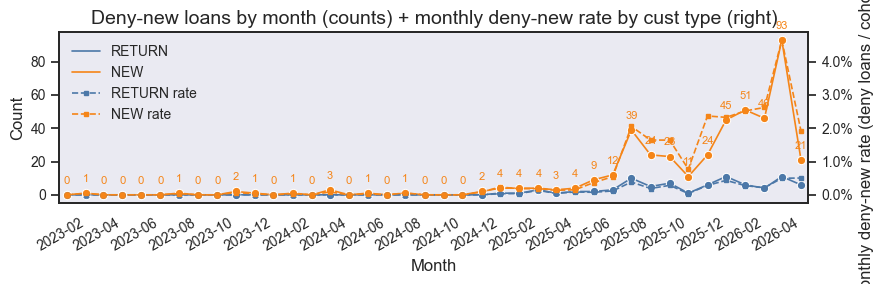

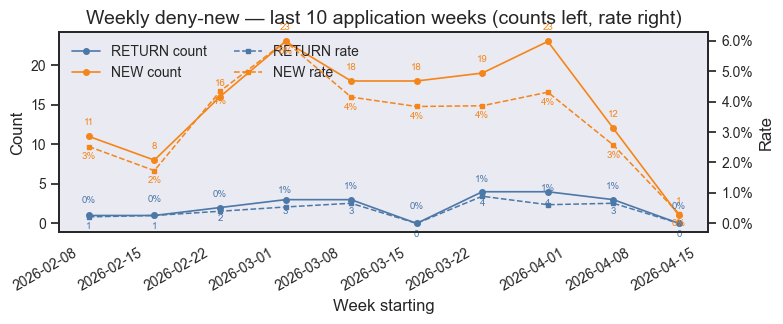

In [13]:
# Deny-new: distinct loans per month (AppYear/AppMonth) since 2023, inst1 normal rows; NEW vs RETURN.

loan_col = 'LoanID'
req = ['AppYear', 'AppMonth', 'CustType', 'isDenyNew', 'InstallmentNumber', loan_col]
miss = [c for c in req if c not in raw_df.columns]
if miss:
    raise ValueError('raw_df missing: ' + ', '.join(miss))

arr = raw_df.get('isArrangementInstall', pd.Series(0, index=raw_df.index)).fillna(0).astype(int)
tp = raw_df.get('is3rdPartyInstall', pd.Series(0, index=raw_df.index)).fillna(0).astype(int)
m = raw_df[(arr == 0) & (tp == 0)].copy()
m = m[pd.to_numeric(m['InstallmentNumber'], errors='coerce').fillna(-1) == 1]
m['CustType'] = m['CustType'].astype(str).str.strip().str.upper()
m = m[m['CustType'].isin(['NEW', 'RETURN'])]

ay = pd.to_numeric(m['AppYear'], errors='coerce')
am = pd.to_numeric(m['AppMonth'], errors='coerce')
m['ym'] = pd.to_datetime(pd.DataFrame({'year': ay, 'month': am, 'day': 1}), errors='coerce')
m = m.dropna(subset=['ym'])
m = m[m['ym'] >= pd.Timestamp('2023-01-01')]

m['deny'] = pd.to_numeric(m['isDenyNew'], errors='coerce').fillna(0).astype(int) == 1
u = m.groupby([loan_col, 'ym', 'CustType'], as_index=False)['deny'].max()
trend = u.groupby(['ym', 'CustType'], as_index=False)['deny'].sum().rename(columns={'deny': 'n_deny_loans'})
# No future calendar months (avoids partial / empty months on the axis)
_cap = pd.Timestamp.today().normalize().replace(day=1)
trend = trend[trend['ym'] <= _cap].copy()

# Monthly deny-new rate (same ym × CustType as counts): n_deny_loans / distinct loans in that bucket.
_mcap = m[m['ym'] <= _cap].copy()
cohort_mt = _mcap.groupby(['ym', 'CustType'], as_index=False)[loan_col].nunique().rename(columns={loan_col: 'n_loans'})
trend_r = trend.merge(cohort_mt, on=['ym', 'CustType'], how='left')
trend_r['deny_rate'] = trend_r['n_deny_loans'] / trend_r['n_loans'].replace(0, np.nan)

display(trend.sort_values(['CustType', 'ym']).reset_index(drop=True))

from util.plot_style import apply_plot_style
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

apply_plot_style(style='white', axes_grid=False)
fig, ax = plt.subplots(figsize=(9, 3))
for ct in ['RETURN', 'NEW']:
    d = trend[trend['CustType'] == ct].sort_values('ym')
    (ln,) = ax.plot(d['ym'], d['n_deny_loans'], linewidth=1.2, label=ct)
    ax.scatter(
        d['ym'],
        d['n_deny_loans'],
        color=ln.get_color(),
        s=36,
        zorder=5,
        edgecolors='white',
        linewidths=0.75,
    )
    if ct == 'NEW':
        for xm, yv in zip(d['ym'], d['n_deny_loans']):
            ax.annotate(
                str(int(yv)),
                (xm, yv),
                textcoords='offset points',
                xytext=(0, 8),
                ha='center',
                fontsize=8,
                color=ln.get_color(),
            )
ax.set_title('Deny-new loans by month (counts) + monthly deny-new rate by cust type (right)')
ax.set_ylabel('Count')
ax.set_xlabel('Month')

ax2 = ax.twinx()
for i, ct in enumerate(['RETURN', 'NEW']):
    dr = trend_r[trend_r['CustType'] == ct].sort_values('ym')
    col = ax.lines[i].get_color() if i < len(ax.lines) else None
    ax2.plot(
        dr['ym'],
        dr['deny_rate'],
        linestyle='--',
        linewidth=1.2,
        color=col,
        marker='s',
        markersize=3,
        label=ct + ' rate',
        zorder=4,
    )
ax2.set_ylabel('Monthly deny-new rate (deny loans / cohort loans)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc='upper left')

_x0, _x1 = trend['ym'].min(), trend['ym'].max()
if pd.notna(_x0) and pd.notna(_x1):
    pad = pd.Timedelta(days=12)
    ax.set_xlim(_x0 - pad, _x1 + pad)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Past 10 weeks: weekly deny-new rate (RETURN vs NEW) ---
_mw = _mcap.copy()
if 'ApplicationDate' in _mw.columns:
    _mw['_ws'] = pd.to_datetime(_mw['ApplicationDate'], errors='coerce').dt.to_period('W-MON').dt.start_time
elif 'AppWeek' in _mw.columns:
    _ay = pd.to_numeric(_mw['AppYear'], errors='coerce')
    _aw = pd.to_numeric(_mw['AppWeek'], errors='coerce')

    def _iso_mon(y, w):
        if pd.isna(y) or pd.isna(w):
            return pd.NaT
        try:
            return pd.Timestamp.fromisocalendar(int(y), int(w), 1)
        except (ValueError, OverflowError):
            return pd.NaT

    _mw['_ws'] = pd.DataFrame({'AppYear': _ay, 'AppWeek': _aw}).apply(lambda r: _iso_mon(r['AppYear'], r['AppWeek']), axis=1)
else:
    _mw = None

if _mw is not None:
    _mw = _mw.dropna(subset=['_ws'])
    if _mw.empty:
        print('Weekly plot skipped: no rows with a valid application week.')
    else:
        _w10 = sorted(_mw['_ws'].unique())[-10:]
        _mw = _mw[_mw['_ws'].isin(_w10)]
        if _mw.empty:
            print('Weekly plot skipped: no rows in last 10 application weeks.')
        else:
            _coh_w = _mw.drop_duplicates([loan_col, '_ws', 'CustType']).groupby(['_ws', 'CustType'], as_index=False)[loan_col].nunique().rename(columns={loan_col: 'n_loans'})
            _dn_w = _mw[_mw['deny']].drop_duplicates([loan_col, '_ws', 'CustType']).groupby(['_ws', 'CustType'], as_index=False)[loan_col].nunique().rename(columns={loan_col: 'n_deny'})
            wkr = _coh_w.merge(_dn_w, on=['_ws', 'CustType'], how='outer').fillna(0)
            wkr['deny_rate'] = wkr['n_deny'] / wkr['n_loans'].replace(0, np.nan)

            fig2, axb = plt.subplots(figsize=(8, 3.4))
            axb2 = axb.twinx()
            for ct in ['RETURN', 'NEW']:
                w = wkr[wkr['CustType'] == ct].sort_values('_ws')
                (ln,) = axb.plot(w['_ws'], w['n_deny'], linewidth=1.2, marker='o', markersize=4, label=ct + ' count')
                off = 8 if ct == 'NEW' else -10
                for xm, yv in zip(w['_ws'], w['n_deny']):
                    axb.annotate(str(int(yv)), (xm, yv), textcoords='offset points', xytext=(0, off), ha='center', fontsize=7, color=ln.get_color())
            for i, ct in enumerate(['RETURN', 'NEW']):
                w = wkr[wkr['CustType'] == ct].sort_values('_ws')
                col = axb.lines[i].get_color() if i < len(axb.lines) else None
                axb2.plot(w['_ws'], w['deny_rate'], linestyle='--', linewidth=1.1, marker='s', markersize=3, color=col, label=ct + ' rate')
                off2 = -9 if ct == 'NEW' else 10
                for xm, rv in zip(w['_ws'], w['deny_rate']):
                    if pd.notna(rv):
                        axb2.annotate(f'{rv:.0%}', (xm, rv), textcoords='offset points', xytext=(0, off2), ha='center', fontsize=7, color=col)
            axb.set_title('Weekly deny-new — last 10 application weeks (counts left, rate right)')
            axb.set_ylabel('Count')
            axb2.set_ylabel('Rate')
            axb.set_xlabel('Week starting')
            axb2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
            h1, l1 = axb.get_legend_handles_labels()
            h2, l2 = axb2.get_legend_handles_labels()
            axb.legend(h1 + h2, l1 + l2, frameon=False, loc='upper left', ncol=2)
            fig2.autofmt_xdate()
            plt.tight_layout()
            plt.show()
else:
    print('Weekly plot skipped: need ApplicationDate or AppYear+AppWeek on raw_df.')


In [7]:
# Raw examples: deny-new (inst1), NEW cust, application (or origination) date 2026-03-23 .. 2026-04-12.

loan_col = 'LoanID'
d0, d1 = pd.Timestamp('2026-04-12'), pd.Timestamp('2026-04-28')

arr = raw_df.get('isArrangementInstall', pd.Series(0, index=raw_df.index)).fillna(0).astype(int)
tp = raw_df.get('is3rdPartyInstall', pd.Series(0, index=raw_df.index)).fillna(0).astype(int)
ex = raw_df[(arr == 0) & (tp == 0)].copy()
ex = ex[pd.to_numeric(ex['InstallmentNumber'], errors='coerce').fillna(-1) == 1]
ex = ex[pd.to_numeric(ex['isDenyNew'], errors='coerce').fillna(0).astype(int) == 1]
ex['CustType'] = ex['CustType'].astype(str).str.strip().str.upper()
ex = ex[ex['CustType'] == 'NEW']

if 'ApplicationDate' in ex.columns:
    ad = pd.to_datetime(ex['ApplicationDate'], errors='coerce')
    ex = ex[(ad >= d0) & (ad <= d1)]
    date_note = 'ApplicationDate'
elif 'OriginationDate' in ex.columns:
    ad = pd.to_datetime(ex['OriginationDate'], errors='coerce')
    ex = ex[(ad >= d0) & (ad <= d1)]
    date_note = 'OriginationDate'
else:
    raise ValueError('raw_df needs ApplicationDate or OriginationDate for this window')

cols = [
    loan_col, 'CustType', 'isDenyNew', 'InstallmentNumber', 'installStatus',
    'ApplicationDate', 'OriginationDate', 'AppYear', 'AppMonth',
    'LoanStatus', 'OriginatedAmount',
]
cols = [c for c in cols if c in ex.columns]
sort_col = 'ApplicationDate' if 'ApplicationDate' in ex.columns else 'OriginationDate'
ex_u = ex.drop_duplicates(subset=[loan_col]).sort_values(sort_col)

print(date_note, 'window:', d0.date(), '->', d1.date(), '| distinct loans:', ex_u[loan_col].nunique())
display(ex_u[cols].head(40))


OriginationDate window: 2026-04-12 -> 2026-04-28 | distinct loans: 22


,LoanID,CustType,isDenyNew,InstallmentNumber,installStatus,OriginationDate,AppYear,AppMonth,LoanStatus,OriginatedAmount
1012146,I2603251-0,NEW,1,1,684,2026-04-13,2026,4,R,800.0
1012099,I2602919-0,NEW,1,1,684,2026-04-13,2026,4,R,900.0
1012122,I2603089-0,NEW,1,1,684,2026-04-13,2026,4,R,700.0
996694,I2599903-0,NEW,1,1,684,2026-04-13,2026,4,R,1000.0
1011290,I2605304-0,NEW,1,1,684,2026-04-14,2026,4,R,550.0
1011198,I2604761-0,NEW,1,1,684,2026-04-14,2026,4,R,800.0
997103,I2605723-0,NEW,1,1,684,2026-04-14,2026,4,R,800.0
997110,I2605776-0,NEW,1,1,684,2026-04-14,2026,4,R,800.0
997107,I2605759-0,NEW,1,1,684,2026-04-15,2026,4,R,1000.0
997266,I2606472-0,NEW,1,1,684,2026-04-15,2026,4,R,800.0


In [9]:
# Export deny-new / NEW table from prior cell (full ex_u[cols], not just head preview)
from pathlib import Path
_out = Path("/Users/starsrain/2025_concord/yieldCurve_augmenting/output_data") / (
    f"jcx_2026_xpd_V1_deny_new_NEW_loans_{d0.date()}_{d1.date()}_{date_note}.xlsx"
)
ex_u[cols].to_excel(_out, index=False, engine="openpyxl")
print("Wrote:", _out.resolve())


Wrote: /Users/starsrain/2025_concord/yieldCurve_augmenting/output_data/jcx_2026_xpd_V1_deny_new_NEW_loans_2026-04-12_2026-04-28_OriginationDate.xlsx
